# FIO iod-bs sweep

Multiple runs per `(bs, iod)` configuration (each run = independent fio job with a fresh dataset).

**Block sizes:** 4k, 16k, 1m, 2m, 4m  
**Queue depths (iodepth):** 4, 8, 16, 32, 64, 128, 256

## Sequential Read

In [1]:
import json, glob, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = "."

records = []
skipped = []
for f in sorted(glob.glob(f"{DATA_DIR}/fio_seq_read_*.json")):
    m = re.match(r".*/fio_seq_read_(bs\w+)_nj1_(iod\d+)_(\d+)\.json", f)
    if not m:
        continue
    bs, iod, ts = m.group(1), m.group(2), m.group(3)
    try:
        with open(f) as fh:
            d = json.load(fh)
        r = d['jobs'][0]['read']
        records.append({
            'bs': bs, 'iod': iod, 'ts': ts,
            'bw_GiBs': r['bw_bytes'] / 2**30,
            'iops': r['iops'],
            'lat_ms': r['lat_ns']['mean'] / 1e6,
        })
    except (json.JSONDecodeError, KeyError) as e:
        skipped.append((f, str(e)))

df = pd.DataFrame(records)

BS_ORDER  = ['bs4k', 'bs16k', 'bs1m', 'bs2m', 'bs4m']
IOD_ORDER = ['iod4', 'iod8', 'iod16', 'iod32', 'iod64', 'iod128', 'iod256']
df['bs']  = pd.Categorical(df['bs'],  categories=BS_ORDER,  ordered=True)
df['iod'] = pd.Categorical(df['iod'], categories=IOD_ORDER, ordered=True)
df['iod_n'] = df['iod'].str.replace('iod', '').astype(int)
df = df.sort_values(['bs', 'iod', 'ts']).reset_index(drop=True)

print(f"Total records: {len(df)}")
if skipped:
    print(f"Skipped {len(skipped)} files:")
    for f, e in skipped:
        print(f"  {f}: {e}")
print("\nRuns per (bs, iod):")
print(df.groupby(['bs', 'iod'], observed=True).size().unstack('iod').to_string())

Total records: 362

Runs per (bs, iod):
iod    iod4  iod8  iod16  iod32  iod64  iod128  iod256
bs                                                    
bs4k     10    11     11     11     11      11      11
bs16k    11    11     11     11     11      11      10
bs1m     10    10     10     10     10      10      10
bs2m     10    10     10     10     10      10      10
bs4m     10    10     10     10     10      10      10


In [2]:
# --- Multi-run stats per (bs, iod): mean, std, CV, min, max ---
stats = (
    df.groupby(['bs', 'iod'], observed=True)['bw_GiBs']
    .agg(
        n_runs='count',
        median='median',
        std='std',
        cv_pct=lambda x: x.std() / x.mean() * 100 if len(x) > 1 else float('nan'),
        min='min',
        max='max',
    )
    .reset_index()
)
stats['spread'] = stats['max'] - stats['min']

pd.set_option('display.float_format', '{:.2f}'.format)
print("BW (GiB/s) statistics across runs per (bs, iod):")
display(stats)


BW (GiB/s) statistics across runs per (bs, iod):


,bs,iod,n_runs,median,std,cv_pct,min,max,spread
0,bs4k,iod4,10,0.10,0.00,0.53,0.10,0.10,0.00
1,bs4k,iod8,11,0.14,0.00,1.09,0.14,0.15,0.01
2,bs4k,iod16,11,0.18,0.00,0.70,0.18,0.18,0.00
3,bs4k,iod32,11,0.28,0.00,0.69,0.27,0.28,0.01
4,bs4k,iod64,11,0.31,0.00,0.67,0.31,0.31,0.01
5,bs4k,iod128,11,0.41,0.00,1.19,0.40,0.41,0.01
6,bs4k,iod256,11,0.40,0.00,0.97,0.39,0.40,0.01
7,bs16k,iod4,11,0.26,0.01,2.59,0.25,0.26,0.02
8,bs16k,iod8,11,0.43,0.01,2.77,0.43,0.46,0.03
9,bs16k,iod16,11,0.82,0.02,2.95,0.77,0.84,0.08


In [3]:
cv_range_sr = (
    stats.groupby("bs", observed=True)["cv_pct"]
    .agg(cv_min="min", cv_max="max")
    .reset_index()
)
print("Sequential Read CV (%) range per block size:")
display(cv_range_sr)

Sequential Read CV (%) range per block size:


,bs,cv_min,cv_max
0,bs4k,0.53,1.19
1,bs16k,0.70,2.95
2,bs1m,26.65,72.59
3,bs2m,49.23,98.86
4,bs4m,52.27,74.91


In [4]:
bw_range_sr = (
    stats.groupby("bs", observed=True)["median"]
    .agg(bw_min="min", bw_max="max")
    .reset_index()
)
print("Sequential Read BW (GiB/s) range per block size (across iodepths):")
display(bw_range_sr)

Sequential Read BW (GiB/s) range per block size (across iodepths):


,bs,bw_min,bw_max
0,bs4k,0.10,0.41
1,bs16k,0.26,1.51
2,bs1m,3.28,19.10
3,bs2m,3.29,19.46
4,bs4m,3.27,18.66


In [5]:
# --- Bimodal mode detection: ceiling (~3.5 GiB/s) vs high-BW per run ---
CEILING_THRESH = 4.2  # GiB/s — below this = serialized-IO mode

df['mode'] = df['bw_GiBs'].apply(lambda x: 'ceiling' if x < CEILING_THRESH else 'parallel')

mode_stats = (
    df.groupby(['bs', 'iod'], observed=True)
    .apply(lambda g: pd.Series({
        'n_runs':       len(g),
        'n_ceiling':    (g['mode'] == 'ceiling').sum(),
        'n_parallel':   (g['mode'] == 'parallel').sum(),
        'pct_ceiling':  (g['mode'] == 'ceiling').mean() * 100,
        'mean_ceiling': g.loc[g['mode'] == 'ceiling', 'bw_GiBs'].mean(),
        'mean_parallel':g.loc[g['mode'] == 'parallel', 'bw_GiBs'].mean(),
    }), include_groups=False)
    .reset_index()
)

# mode_stats


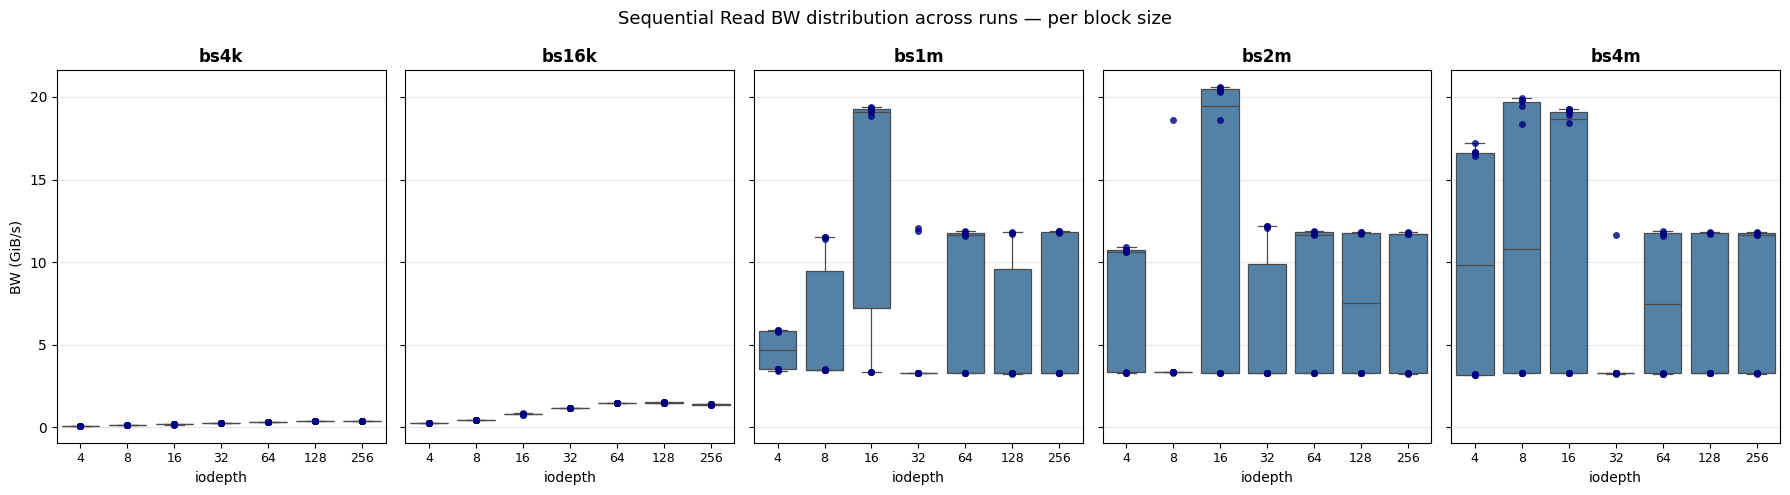

In [6]:
# --- BW distribution: 5 box plots, one per block size ---
IOD_NUMS = [int(i.replace('iod', '')) for i in IOD_ORDER]

fig, axes = plt.subplots(1, 5, figsize=(18, 5), sharey=True)

for ax, bs in zip(axes, BS_ORDER):
    sub = df[df['bs'] == bs].copy()
    sub['iod_n'] = sub['iod_n'].astype(int)

    sns.boxplot(
        data=sub, x='iod_n', y='bw_GiBs',
        order=IOD_NUMS,
        ax=ax, color='steelblue', linewidth=0.9,
        fliersize=0,   # hide default outlier markers; strip plot handles points
    )
    # overlay individual run points
    sns.stripplot(
        data=sub, x='iod_n', y='bw_GiBs',
        order=IOD_NUMS,
        ax=ax, size=5, color='navy', alpha=0.8, jitter=False,
    )

    ax.set_title(bs, fontweight='bold')
    ax.set_xlabel('iodepth')
    ax.set_ylabel('BW (GiB/s)' if ax == axes[0] else '')
    ax.tick_params(axis='x', labelsize=9)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Sequential Read BW distribution across runs — per block size', fontsize=13)
plt.tight_layout()
plt.savefig('boxplot_seqread_bw.pdf', bbox_inches='tight')
plt.show()

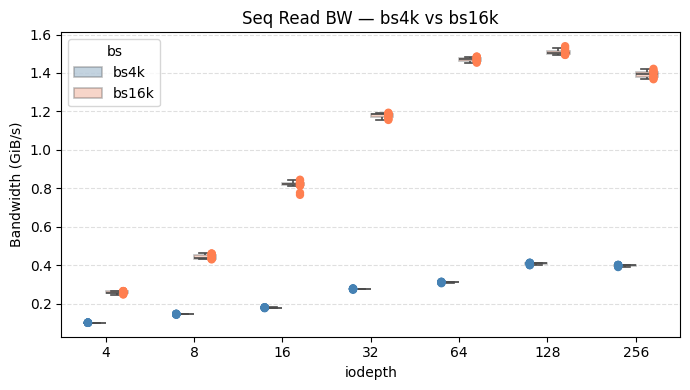

In [7]:
# --- 4k and 16k BW in one chart ---
sub_small = df[df["bs"].isin(["bs4k", "bs16k"])].copy()
sub_small["bs"] = sub_small["bs"].cat.remove_unused_categories()

fig, ax = plt.subplots(figsize=(7, 4))

palette = {"bs4k": "steelblue", "bs16k": "coral"}

sns.boxplot(
    data=sub_small, x="iod_n", y="bw_GiBs", hue="bs",
    order=IOD_NUMS, hue_order=["bs4k", "bs16k"],
    palette=palette, width=0.5, fliersize=0, linewidth=1.2,
    boxprops=dict(alpha=0.35), ax=ax,
)
sns.stripplot(
    data=sub_small, x="iod_n", y="bw_GiBs", hue="bs",
    order=IOD_NUMS, hue_order=["bs4k", "bs16k"],
    palette=palette, size=6, jitter=False, dodge=True,
    legend=False, ax=ax,
)

ax.set_xlabel("iodepth")
ax.set_ylabel("Bandwidth (GiB/s)")
ax.set_title("Seq Read BW — bs4k vs bs16k")
ax.legend(title="bs")
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### Findings

**CV heatmap (run-to-run variability):**
- Small block sizes (4k, 16k): CV is low across all iodepths — reproducible.
- Large block sizes (1m, 2m, 4m): high CV at many (bs, iod) cells, driven by the bimodal ceiling/parallel split. A cell with 50% ceiling + 50% parallel runs will have very high CV.

**Ceiling-mode heatmap:**
- Identifies which (bs, iod) cells are non-deterministically entering the ~3.5 GiB/s serialized-IO mode.
- Cells with 0% ceiling are reliably in the parallel (high-BW) regime.
- Cells with 100% ceiling are stuck in serialized mode regardless of run.
- Cells with mixed % represent the non-deterministic regime — DAOS object placement at write time determines which mode is hit.

**Interpretation:** The fraction of ceiling-mode runs is a more informative signal than mean BW or CV alone for large-BS configurations. The non-determinism is attributable to DAOS stripe placement; fixing the object class (e.g., `OC_SX`) in the DFS container config would eliminate this bimodality.

/var/folders/15/mf0_kxd52z1_d06fgmyq4kdm000_st/T/ipykernel_48748/1735957926.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7, loc='upper right', framealpha=0.7)


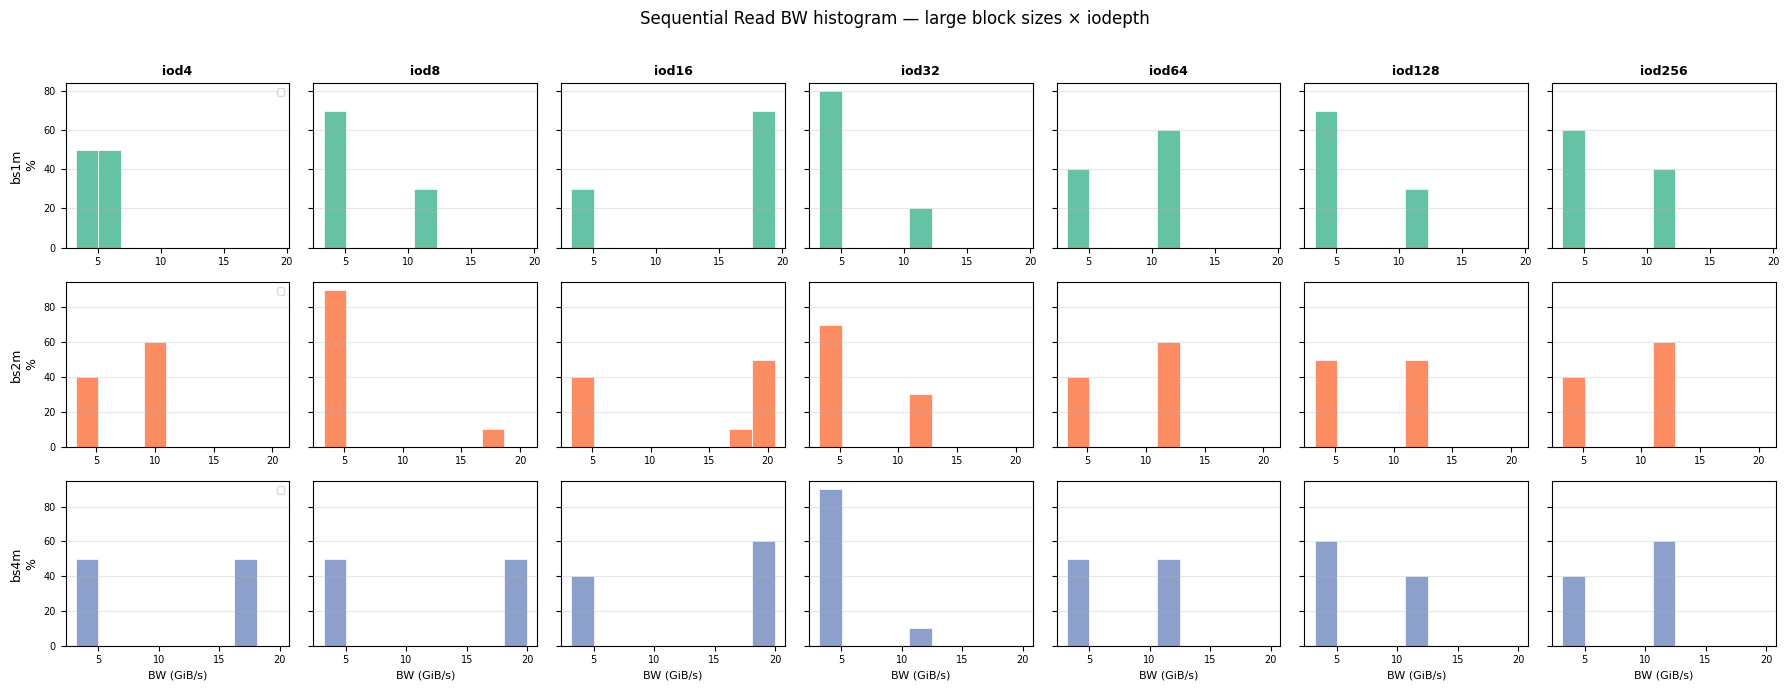

In [8]:
# --- BW histogram for larger block sizes (1m, 2m, 4m), faceted by iodepth ---
LARGE_BS  = ['bs1m', 'bs2m', 'bs4m']
IOD_NUMS  = [int(i.replace('iod', '')) for i in IOD_ORDER]
colors    = sns.color_palette("Set2", len(LARGE_BS))

fig, axes = plt.subplots(len(LARGE_BS), len(IOD_NUMS),
                         figsize=(18, 7), sharey='row', sharex='row')

for row, (bs, color) in enumerate(zip(LARGE_BS, colors)):
    bs_data = df[df['bs'] == bs]['bw_GiBs']
    bins = np.linspace(bs_data.min(), bs_data.max(), 10)  # shared bin edges across the row
    for col, iod_n in enumerate(IOD_NUMS):
        ax  = axes[row][col]
        sub = df[(df['bs'] == bs) & (df['iod_n'] == iod_n)]['bw_GiBs']
        weights = np.ones(len(sub)) / len(sub) * 100
        ax.hist(sub, bins=bins, weights=weights, color=color, edgecolor='white', linewidth=0.5)
        if col == 0:
            ax.legend(fontsize=7, loc='upper right', framealpha=0.7)
        if row == 0:
            ax.set_title(f'iod{iod_n}', fontsize=9, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f'{bs}\n%', fontsize=9)
        ax.set_xlabel('BW (GiB/s)' if row == len(LARGE_BS) - 1 else '', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(axis='y', alpha=0.3)

fig.suptitle('Sequential Read BW histogram — large block sizes × iodepth\n', fontsize=12)
plt.tight_layout()
plt.savefig('histogram_seqread_bw_large_bs.pdf', bbox_inches='tight')
plt.show()

## Random Write

In [9]:
rw_records = []
rw_skipped = []
for f in sorted(glob.glob(f"{DATA_DIR}/fio_rand_write_*.json")):
    m = re.match(r".*/fio_rand_write_(bs\w+)_nj1_(iod\d+)_(\d+)\.json", f)
    if not m:
        continue
    bs, iod, ts = m.group(1), m.group(2), m.group(3)
    try:
        with open(f) as fh:
            d = json.load(fh)
        w = d['jobs'][0]['write']
        rw_records.append({
            'bs': bs, 'iod': iod, 'ts': ts,
            'bw_GiBs': w['bw_bytes'] / 1024**3,
            'iops': w['iops'],
            'lat_ms': w['lat_ns']['mean'] / 1e6,
        })
    except (json.JSONDecodeError, KeyError) as e:
        rw_skipped.append((f, str(e)))

rw_df = pd.DataFrame(rw_records)
rw_df['bs']  = pd.Categorical(rw_df['bs'],  categories=BS_ORDER,  ordered=True)
rw_df['iod'] = pd.Categorical(rw_df['iod'], categories=IOD_ORDER, ordered=True)
rw_df['iod_n'] = rw_df['iod'].str.replace('iod', '').astype(int)
rw_df = rw_df.sort_values(['bs', 'iod', 'ts']).reset_index(drop=True)

print(f"Total records: {len(rw_df)}")
if rw_skipped:
    print(f"Skipped {len(rw_skipped)} files:")
    for f, e in rw_skipped:
        print(f"  {f}: {e}")
print("\nRuns per (bs, iod):")
print(rw_df.groupby(['bs', 'iod'], observed=True).size().unstack('iod').to_string())

Total records: 385

Runs per (bs, iod):
iod    iod4  iod8  iod16  iod32  iod64  iod128  iod256
bs                                                    
bs4k     11    11     11     11     11      11      11
bs16k    11    11     11     11     11      11      11
bs1m     11    11     11     11     11      11      11
bs2m     11    11     11     11     11      11      11
bs4m     11    11     11     11     11      11      11


In [10]:
# --- Multi-run stats per (bs, iod) ---
rw_stats = (
    rw_df.groupby(['bs', 'iod'], observed=True)['bw_GiBs']
    .agg(
        n_runs='count',
        mean='mean',
        std='std',
        cv_pct=lambda x: x.std() / x.mean() * 100 if len(x) > 1 else float('nan'),
        min='min',
        max='max',
    )
    .reset_index()
)
rw_stats['spread'] = rw_stats['max'] - rw_stats['min']
print("Random Write BW (GiB/s) statistics across runs per (bs, iod):")
display(rw_stats)

Random Write BW (GiB/s) statistics across runs per (bs, iod):


,bs,iod,n_runs,mean,std,cv_pct,min,max,spread
0,bs4k,iod4,11,0.40,0.02,3.97,0.38,0.42,0.04
1,bs4k,iod8,11,0.61,0.01,1.97,0.59,0.62,0.04
2,bs4k,iod16,11,0.64,0.01,1.67,0.63,0.66,0.03
3,bs4k,iod32,11,0.66,0.01,1.46,0.64,0.68,0.04
4,bs4k,iod64,11,0.67,0.01,1.75,0.65,0.68,0.03
5,bs4k,iod128,11,0.68,0.01,1.11,0.67,0.69,0.02
6,bs4k,iod256,11,0.69,0.01,1.75,0.67,0.70,0.03
7,bs16k,iod4,11,1.28,0.10,7.82,1.19,1.39,0.21
8,bs16k,iod8,11,1.98,0.02,1.05,1.95,2.02,0.07
9,bs16k,iod16,11,2.09,0.03,1.33,2.06,2.15,0.09


In [11]:
cv_range_rw = (
    rw_stats.groupby("bs", observed=True)["cv_pct"]
    .agg(cv_min="min", cv_max="max")
    .reset_index()
)
print("Random Write CV (%) range per block size:")
display(cv_range_rw)

Random Write CV (%) range per block size:


,bs,cv_min,cv_max
0,bs4k,1.11,3.97
1,bs16k,0.95,7.82
2,bs1m,1.71,5.39
3,bs2m,2.01,5.91
4,bs4m,1.32,6.40


In [12]:
bw_range_rw = (
    rw_stats.groupby("bs", observed=True)
    .agg(bw_min=("min", "min"), bw_max=("max", "max"))
    .reset_index()
)
print("Random Write BW (GiB/s) range per block size (across iodepths):")
display(bw_range_rw)

Random Write BW (GiB/s) range per block size (across iodepths):


,bs,bw_min,bw_max
0,bs4k,0.38,0.70
1,bs16k,1.19,2.30
2,bs1m,11.07,18.93
3,bs2m,13.61,20.54
4,bs4m,14.72,20.92


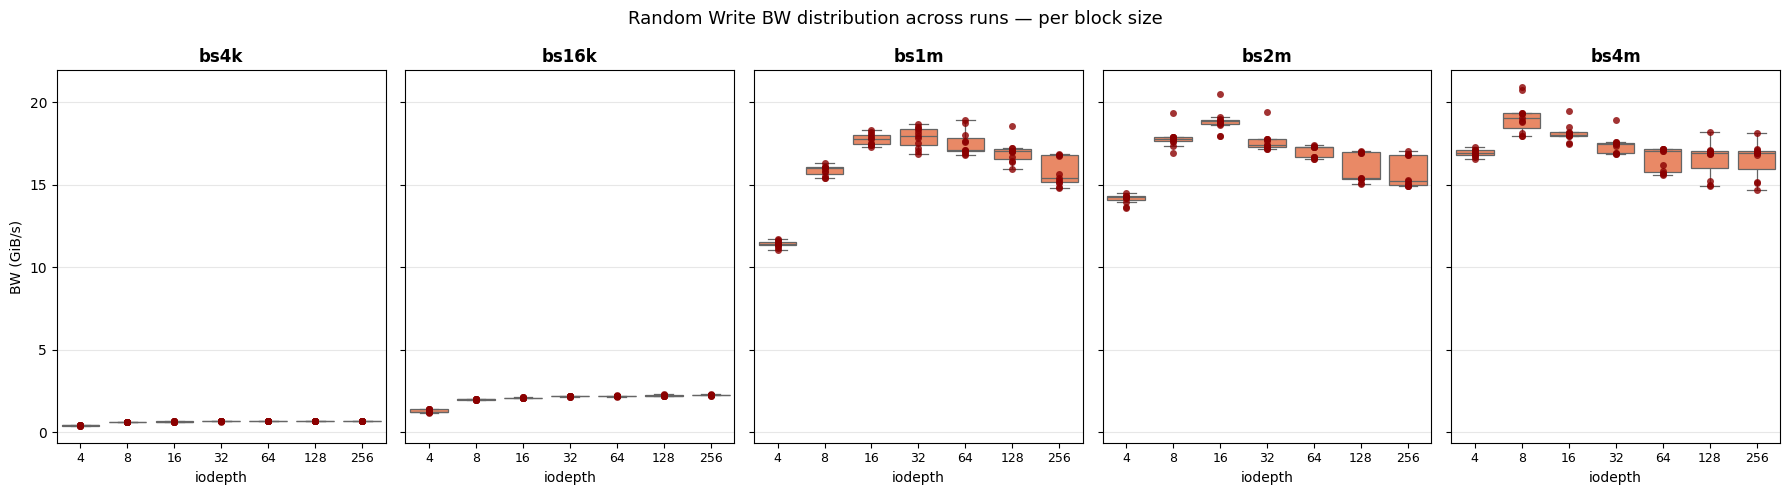

In [13]:
# --- BW distribution: box + strip plots, one per block size ---
IOD_NUMS = [int(i.replace('iod', '')) for i in IOD_ORDER]

fig, axes = plt.subplots(1, 5, figsize=(18, 5), sharey=True)

for ax, bs in zip(axes, BS_ORDER):
    sub = rw_df[rw_df['bs'] == bs].copy()
    sns.boxplot(
        data=sub, x='iod_n', y='bw_GiBs', order=IOD_NUMS,
        ax=ax, color='coral', linewidth=0.9, fliersize=0,
    )
    sns.stripplot(
        data=sub, x='iod_n', y='bw_GiBs', order=IOD_NUMS,
        ax=ax, size=5, color='darkred', alpha=0.8, jitter=False,
    )
    ax.set_title(bs, fontweight='bold')
    ax.set_xlabel('iodepth')
    ax.set_ylabel('BW (GiB/s)' if ax == axes[0] else '')
    ax.tick_params(axis='x', labelsize=9)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Random Write BW distribution across runs — per block size', fontsize=13)
plt.tight_layout()
plt.savefig('boxplot_randwrite_bw.pdf', bbox_inches='tight')
plt.show()

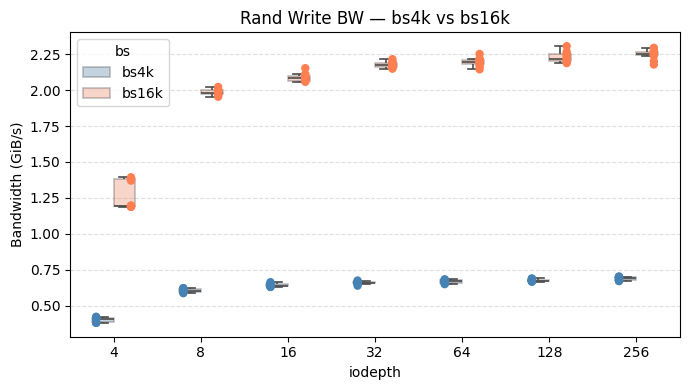

In [14]:
# --- 4k and 16k rand write BW in one chart ---
sub_small_rw = rw_df[rw_df["bs"].isin(["bs4k", "bs16k"])].copy()
sub_small_rw["bs"] = sub_small_rw["bs"].cat.remove_unused_categories()

fig, ax = plt.subplots(figsize=(7, 4))

palette = {"bs4k": "steelblue", "bs16k": "coral"}

sns.boxplot(
    data=sub_small_rw, x="iod_n", y="bw_GiBs", hue="bs",
    order=IOD_NUMS, hue_order=["bs4k", "bs16k"],
    palette=palette, width=0.5, fliersize=0, linewidth=1.2,
    boxprops=dict(alpha=0.35), ax=ax,
)
sns.stripplot(
    data=sub_small_rw, x="iod_n", y="bw_GiBs", hue="bs",
    order=IOD_NUMS, hue_order=["bs4k", "bs16k"],
    palette=palette, size=6, jitter=False, dodge=True,
    legend=False, ax=ax,
)

ax.set_xlabel("iodepth")
ax.set_ylabel("Bandwidth (GiB/s)")
ax.set_title("Rand Write BW — bs4k vs bs16k")
ax.legend(title="bs")
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

bs4k and bs16k are the most stable configurations, with CV below 4.2% and 8.2% respectively, and no run-to-run mode switching. Bandwidth saturates quickly with increasing iodepth: bs4k plateaus near 0.67–0.69 GiB/s from iodepth 32 onward, while bs16k reaches ~2.18–2.24 GiB/s from iodepth 32 onward. Both block sizes are IOPS-bound rather than bandwidth-bound, and their behavior is deterministic and predictable across repeated runs.

### BW and CPU utilization — all configs, shared x-axis and legend

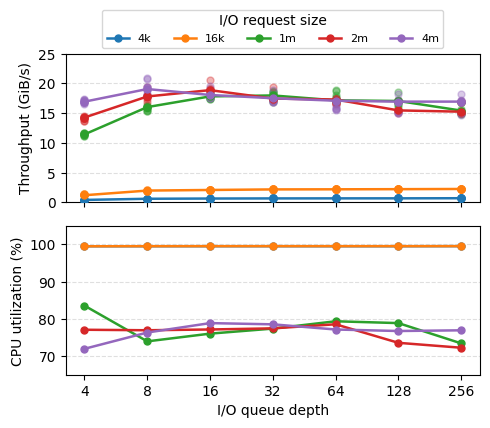

In [17]:
# --- BW (top) + aggregated CPU utilization (bottom), rand write, shared x-axis + legend ---
cpu_records = []
for f in sorted(glob.glob(f"{DATA_DIR}/fio_rand_write_*.json")):
    m = re.match(r".*/fio_rand_write_(bs\w+)_nj1_(iod\d+)_(\d+)\.json", f)
    if not m:
        continue
    bs, iod, ts = m.group(1), m.group(2), m.group(3)
    try:
        with open(f) as fh:
            d = json.load(fh)
        job = d['jobs'][0]
        cpu_records.append({
            'bs': bs, 'iod': iod, 'ts': ts,
            'cpu_pct': job['usr_cpu'] + job['sys_cpu'],
        })
    except (json.JSONDecodeError, KeyError):
        pass

cpu_df = pd.DataFrame(cpu_records)
cpu_df['bs']  = pd.Categorical(cpu_df['bs'],  categories=BS_ORDER,  ordered=True)
cpu_df['iod'] = pd.Categorical(cpu_df['iod'], categories=IOD_ORDER, ordered=True)
cpu_df['iod_n'] = cpu_df['iod'].str.replace('iod', '').astype(int)

IOD_NUMS = [int(i.replace('iod', '')) for i in IOD_ORDER]
palette  = sns.color_palette("tab10", n_colors=len(BS_ORDER))

fig, (ax_bw, ax_cpu) = plt.subplots(2, 1, figsize=(5, 4), sharex=True)

for bs, color in zip(BS_ORDER, palette):
    label = bs.replace('bs', '')

    sub_bw = rw_df[rw_df['bs'] == bs].sort_values('iod_n')
    ax_bw.scatter(sub_bw['iod_n'], sub_bw['bw_GiBs'], color=color, alpha=0.35, s=25, zorder=3)
    med_bw = sub_bw.groupby('iod_n', sort=True)['bw_GiBs'].median().reset_index()
    ax_bw.plot(med_bw['iod_n'], med_bw['bw_GiBs'], color=color, linewidth=1.8,
               marker='o', markersize=5, label=label, zorder=4)

    sub_cpu = cpu_df[cpu_df['bs'] == bs].sort_values('iod_n')
    # ax_cpu.scatter(sub_cpu['iod_n'], sub_cpu['cpu_pct'], color=color, alpha=0.35, s=25, zorder=3)
    med_cpu = sub_cpu.groupby('iod_n', sort=True)['cpu_pct'].median().reset_index()
    ax_cpu.plot(med_cpu['iod_n'], med_cpu['cpu_pct'], color=color, linewidth=1.8,
                marker='o', markersize=5, zorder=4)

ax_bw.set_xscale('log', base=2)
ax_bw.set_ylabel('Throughput (GiB/s)')
ax_bw.set_ylim(0, 25)
ax_bw.yaxis.grid(True, linestyle='--', alpha=0.4)
ax_bw.set_axisbelow(True)

ax_cpu.set_ylabel('CPU utilization (%)')
ax_cpu.set_ylim(65, 105)
ax_cpu.set_xticks(IOD_NUMS)
ax_cpu.set_xticklabels(IOD_NUMS)
ax_cpu.set_xlabel('I/O queue depth')
ax_cpu.yaxis.grid(True, linestyle='--', alpha=0.4)
ax_cpu.set_axisbelow(True)

fig.legend(title='I/O request size', loc='lower center', bbox_to_anchor=(0.5, 1.0),
           ncol=len(BS_ORDER), framealpha=0.8, fontsize=8, bbox_transform=ax_bw.transAxes)

plt.tight_layout()
plt.savefig('fio-randwrite_bs-iod-sweep.pdf', bbox_inches='tight')
plt.show()